In [85]:
import numpy as np
import keras
from keras.datasets import mnist
from keras.models import Model
from keras.layers import Dense,Input
from keras.layers import Conv2D,MaxPooling2D,Dropout,Flatten
from keras import backend as k




#Create the train data and the test data
(x_train,y_train),(x_test,y_test) = mnist.load_data()




img_rows,img_cols=28,28

if k.image_data_format()=='channels_first':
    x_train=x_train.reshape(x_train.shape[0],1,img_rows,img_cols)
    x_test=x_test.reshape(x_test.shape[0],1,img_rows,img_cols)
    inpx=(1,img_rows,img_cols)
else:
    x_train=x_train.reshape(x_train.shape[0],img_rows,img_cols,1)
    x_test=x_test.reshape(x_test.shape[0],img_rows,img_cols,1)
    inpx=(img_rows,img_cols,1)

x_train=x_train.astype('float32')
x_test=x_test.astype('float32')
x_train/=255
x_test/=255






y_train=keras.utils.to_categorical(y_train)
y_test=keras.utils.to_categorical(y_test)






#Build the model
inpx=Input(shape=inpx)
layer1=Conv2D(32,kernel_size=(3,3),activation='relu')(inpx)
layer2=Conv2D(64,(3,3),activation='relu')(layer1)
layer3=MaxPooling2D(pool_size=(3,3))(layer2)
layer4=Dropout(0.25)(layer3)
layer5=Flatten()(layer4)
layer6=Dense(250,activation='sigmoid')(layer5)
layer7=Dense(10,activation='softmax')(layer6)




#Train the CNN(caling compile and fit function)
model = Model([inpx],layer7)
model.compile(optimizer=keras.optimizers.Adadelta(),loss=keras.losses.categorical_crossentropy,metrics=["accuracy"])
model.fit(x_train,y_train,epochs=20,batch_size=500)


Epoch 1/20
120/120 [==============================] - 27s 225ms/step - loss: 2.3998 - accuracy: 0.0975
Epoch 2/20
120/120 [==============================] - 27s 223ms/step - loss: 2.3878 - accuracy: 0.0975
Epoch 3/20
120/120 [==============================] - 28s 230ms/step - loss: 2.3760 - accuracy: 0.0975
Epoch 4/20
120/120 [==============================] - 27s 226ms/step - loss: 2.3645 - accuracy: 0.0975
Epoch 5/20
120/120 [==============================] - 27s 222ms/step - loss: 2.3533 - accuracy: 0.0975
Epoch 6/20
120/120 [==============================] - 27s 223ms/step - loss: 2.3424 - accuracy: 0.0975
Epoch 7/20
120/120 [==============================] - 26s 220ms/step - loss: 2.3318 - accuracy: 0.0975
Epoch 8/20
120/120 [==============================] - 27s 221ms/step - loss: 2.3213 - accuracy: 0.0975
Epoch 9/20
120/120 [==============================] - 27s 222ms/step - loss: 2.3105 - accuracy: 0.0976
Epoch 10/20
120/120 [==============================] - 27s 223ms/step - l

In [86]:
#Evaluate Function
score = model.evaluate(x_test,y_test,verbose=0)
print("loss-",score[0])
print("accuracy-",score[1])


loss- 2.1767613887786865
accuracy- 0.4643000066280365


In [87]:
y_predicted_by_model = model.predict(x_test)

313/313 [==============================] - 1s 4ms/step


In [88]:
y_predicted_by_model[0]

array([0.09775445, 0.10086212, 0.09591299, 0.10382083, 0.09487315,
       0.08688154, 0.06969917, 0.13121189, 0.11367542, 0.10530844],
      dtype=float32)

In [89]:
np.argmax(y_predicted_by_model[2])

8

In [90]:
np.argmax(y_test[2])


1

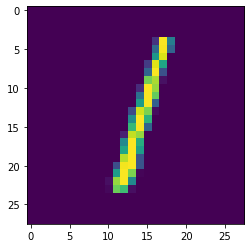

In [91]:
import matplotlib.pyplot as plt
plt.imshow(x_test[2])